# Hyperparameters

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro

from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

GENESET="004"
DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{GENESET}/depleted_versions"
TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
METHOD_NAME = "gradient_score_nebula"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      "gradient_score" # SPECIFIC FOR THIS ANALYSIS
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

# Create Covs and update .qs File

Each method will add its covaritates in .qs obj (needed for Nebula).

In [2]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    dataset_path_h5ad = os.path.join(DATASET_FOLDER, f"{dataset}.h5ad")
    dataset_path_qs = os.path.join(DATASET_FOLDER, f"{dataset}.qs")
    cov_df_csv_path = os.path.join(results_folder, "covariates_df.csv")
    os.makedirs(results_folder, exist_ok=True)

    ###################

    # Logic to calcualte specific Covs --> df with covariates (cov_df_csv_path)


    ##################

    # Update obs of .qs obj
    # add_metadata_to_qs(
    #     base_qs_path=dataset_path_qs,
    #     new_metadata_df=pd.read_csv(cov_df_csv_path),
    #     barcode_col="barcode",
    # )

    #break


######
 Processing dataset: depleted_0.00_dorsal_matrix 
######


######
 Processing dataset: depleted_0.10_dorsal_matrix 
######


######
 Processing dataset: depleted_0.20_dorsal_matrix 
######


######
 Processing dataset: depleted_0.30_dorsal_matrix 
######


######
 Processing dataset: depleted_0.40_dorsal_matrix 
######


######
 Processing dataset: depleted_0.50_dorsal_matrix 
######


######
 Processing dataset: depleted_0.60_dorsal_matrix 
######


######
 Processing dataset: depleted_0.70_dorsal_matrix 
######


######
 Processing dataset: depleted_0.80_dorsal_matrix 
######



# DEG

In [3]:
for dataset in sorted(os.listdir(DATASET_FOLDER), reverse=True):

    #dataset="depleted_0.40_dorsal_matrix"


    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")
    print(save_csv_path)

    if os.path.exists(save_csv_path):
        continue

    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = dataset_path_qs,
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 30, # (MORE gene chunks = LESS RAM per chunk)
        n_cores = 25, # (FEWER parallel jobs = LESS total RAM)
        save_tmp = False,
        suffix = None,
    )

    # save csv
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{save_csv_path}", row.names = FALSE)
    ''')

    #break

    


######
 Processing dataset: depleted_0.80_dorsal_matrix 
######

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.80_dorsal_matrix/gradient_score_nebula/depleted_0.80_dorsal_matrix-gradient_score_nebula_results.csv

######
 Processing dataset: depleted_0.70_dorsal_matrix 
######

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.70_dorsal_matrix/gradient_score_nebula/depleted_0.70_dorsal_matrix-gradient_score_nebula_results.csv

######
 Processing dataset: depleted_0.60_dorsal_matrix 
######

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.60_dorsal_matrix/gradient_score_nebula/depleted_0.60_dorsal_matrix-gradient_score_nebula_results.csv

######
 Processing dataset: depleted_0.50_dorsal_matrix 
######

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.50_dorsal_matrix/gradient_score_nebula/depleted_0

***** LOADING sobj: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.40_dorsal_matrix/depleted_0.40_dorsal_matrix.qs
Splitting 37905 genes into 30 chunks
Skipping /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.40_dorsal_matrix/depleted_0.40_dorsal_matrix__nebula_ln/chunks/chunk_001_of_030.qs (already exists)
Skipping /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.40_dorsal_matrix/depleted_0.40_dorsal_matrix__nebula_ln/chunks/chunk_002_of_030.qs (already exists)
Skipping /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.40_dorsal_matrix/depleted_0.40_dorsal_matrix__nebula_ln/chunks/chunk_003_of_030.qs (already exists)
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.40_dorsal_matrix/depleted_0.40_dorsal_matrix__nebula_ln/chunks/chunk_004_of_030.qs (genes 3793 -->

2026-02-10 22:19:43 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  



######
 Processing dataset: depleted_0.30_dorsal_matrix 
######

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.30_dorsal_matrix/gradient_score_nebula/depleted_0.30_dorsal_matrix-gradient_score_nebula_results.csv
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.30_dorsal_matrix/depleted_0.30_dorsal_matrix.qs --id-col donor_id --offset-col nCount_RNA --n-folds 30 --n-cores 25 --save-tmp 0 --covs case_control,Age.at.Death,Sex,PMI,pct_mt,pct_intronic,gradient_score
[INFO] Input: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.30_dorsal_matrix/depleted_0.30_dorsal_matrix.qs
[INFO] Script dir: /home/gdallagl/myworkdir/XDP/utils/nebula_scripts
[INFO] Base name: depleted_0.30_dorsal_matrix.qs
[INFO] Geneset dir: /home/gdallagl/myworkdir/data/XDP/arti

# Plot Results

In [4]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,RAB29,1.788889,0.7,7,"MD6927,MD9129,MS706984,MS876075,MS986638,UMBEB..."
1,SHCBP1,-0.944444,0.7,7,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
2,INO80C,1.155556,0.7,7,"MD6927,MD9129,MS30499,MS986638,UMBEB22074,UMBE..."
3,ENSG00000234185,0.522222,0.3,3,"MD9129,MS706984,MS876075"
4,PPIH,-1.155556,0.4,4,"MS706984,MS986638,UMBEB23158,UMBEB24013"
...,...,...,...,...,...
395,ZNF780A,-0.944444,0.6,6,"MS30499,MS706984,UMBEB22074,UMBEB23076,UMBEB23..."
396,NBEA,-0.944444,0.8,8,"MD6927,MD9129,MS30499,MS876075,MS986638,UMBEB2..."
397,EPB41L1-AS1,0.733333,0.4,4,"MD9129,UMBEB23076,UMBEB23158,UMBEB24013"
398,TCTE1,-1.788889,1.0,10,"MD6927,MD9129,MS30499,MS706984,MS876075,MS9866..."



######
 Processing dataset: depleted_0.00_dorsal_matrix 
######



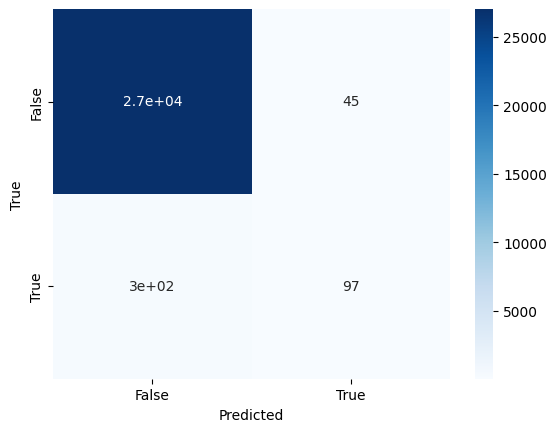

Precision: 0.683
Recall:    0.242
F1 Score:  0.358
Accuracy:  0.987
Clipping 24 genes with -log10(p) > 10


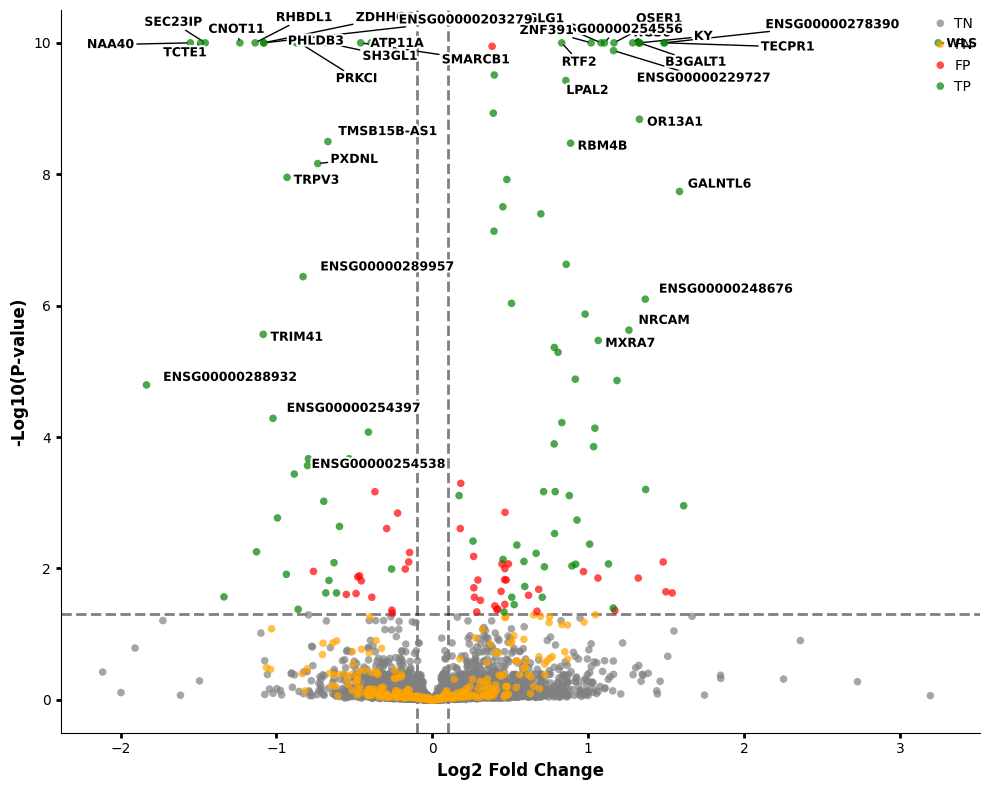

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.113721,0.011790,0.479980,False,False,0.318777,TN,-0.036252
1,A1BG-AS1,-0.025827,0.633348,0.948777,False,False,0.022836,TN,-0.000590
2,A1CF,-0.238748,0.007326,0.410365,False,False,0.386830,TN,-0.092355
3,A2M,0.271460,0.083669,0.810938,False,False,0.091012,TN,0.024706
4,A2M-AS1,0.046509,0.437802,0.918970,False,False,0.036699,TN,0.001707
...,...,...,...,...,...,...,...,...,...
27475,ZZEF1,-0.022206,0.414542,0.918970,False,False,0.036699,TN,-0.000815
27476,ZZZ3,0.046481,0.405155,0.917626,False,False,0.037334,TN,0.001735
27477,ENSG00000205653,0.451566,0.501272,0.930773,False,False,0.031156,TN,0.014069
27478,ENSG00000223438,0.023911,0.972119,0.995559,False,False,0.001933,TN,0.000046


In [5]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")

    df_nebula = pd.read_csv(save_csv_path)

    DEG.plot_nebula_results(df_nebula, 
                    df_true_degs, 
                    col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_gene="gene",
                    PVAL_THR=PVAL_THR,
                    LOGFC_THR=LOGFC_THR,
                    max_FDR=10,
                    add_adj_p_col=True
                    )
    break